In [1]:
# 🤖 MACHINE LEARNING FOR COMPLETE BEGINNERS
# Environmental Impact Prediction from Biomass Gasification
# 
# 👋 Welcome! This is your first machine learning project!
# 
# 🎯 WHAT WE'RE TRYING TO DO:
# Imagine you're a chef trying to predict how a dish will taste based on:
# - Cooking temperature 🌡️
# - Cooking time ⏰  
# - Ingredients used 🥕
#
# Similarly, we want to predict ENVIRONMENTAL IMPACTS based on:
# - Process temperature 🌡️
# - Process pressure 💨
# - Gas yields produced ⚗️
# - Technology type used 🔧
#
# 🧠 HOW MACHINE LEARNING WORKS:
# 1. Collect Examples: Gather data from past experiments
# 2. Find Patterns: Let the computer discover relationships  
# 3. Make Predictions: Use those patterns to predict new scenarios
# 4. Check Accuracy: See how close our predictions are to reality

print("🎉 Welcome to Machine Learning for Beginners!")
print("📚 Today you'll learn to predict environmental impacts!")

# STEP 1: Import our "tools" (libraries)
# Think of these as different tools in a toolbox - each one helps us do specific tasks

# Data handling tools (like Excel, but more powerful)
import pandas as pd
import numpy as np

# Visualization tools (for making charts and graphs)
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning tools (the main event!)
from sklearn.model_selection import train_test_split  # Split data into training/testing
from sklearn.preprocessing import StandardScaler, LabelEncoder  # Prepare data for ML
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor  # Our ML algorithms
from sklearn.multioutput import MultiOutputRegressor  # For predicting multiple things at once
from sklearn.linear_model import Ridge  # Another type of ML algorithm
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error  # For measuring accuracy
from sklearn.impute import SimpleImputer  # For handling missing data
import joblib  # For saving our trained model
import warnings
warnings.filterwarnings('ignore')  # Hide technical warning messages

# Make our charts look nice
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print("✅ All tools imported successfully!")
print("🎯 Ready to start machine learning!")
print("\n💡 WHAT EACH TOOL DOES:")
print("  📊 pandas = Data tables (like Excel)")
print("  🧮 numpy = Math calculations")
print("  📈 matplotlib/seaborn = Making graphs")
print("  🤖 sklearn = Machine learning algorithms")


🎉 Welcome to Machine Learning for Beginners!
📚 Today you'll learn to predict environmental impacts!
✅ All tools imported successfully!
🎯 Ready to start machine learning!

💡 WHAT EACH TOOL DOES:
  📊 pandas = Data tables (like Excel)
  🧮 numpy = Math calculations
  📈 matplotlib/seaborn = Making graphs
  🤖 sklearn = Machine learning algorithms


In [2]:
# 📊 STEP 2: Load Our Data (The Ingredients for ML)
#
# 🤔 WHAT IS DATA?
# Data is like a recipe book filled with examples from past experiments.
# Each row = one experiment, each column = one measurement
#
# 🎯 WE HAVE TWO TYPES OF DATA:
# 1. OPERATIONAL DATA (the "recipe") - what conditions were used:
#    - Temperature: How hot the reaction was
#    - Pressure: How much pressure was applied  
#    - Technology: Which method was used (steam, plasma, etc.)
#    - Yields: How much gas was produced
#
# 2. ENVIRONMENTAL DATA (the "results") - what impacts occurred:
#    - Climate change contribution
#    - Water usage
#    - Toxicity levels
#    - And 15 more environmental indicators...

print("📊 STEP 2: Loading our experimental data...")
print("Think of this like opening a recipe book with past experiments!")

# Load the operational data (our "recipe ingredients")
print("\n🔬 Loading operational gasification data...")
operational_df = pd.read_csv('data/gasification_data_refined.csv')

print(f"✅ Data loaded successfully!")
print(f"📏 Size: {operational_df.shape[0]} experiments × {operational_df.shape[1]} parameters")
print(f"\n🔧 Technologies we studied: {list(operational_df['technology'].unique())}")

print(f"\n📈 Key measurements in our data:")
print(f"   🌡️  Temperature range: {operational_df['temperature_C'].min():.0f}°C to {operational_df['temperature_C'].max():.0f}°C")
print(f"   💨 Pressure range: {operational_df['pressure_bar'].min():.1f} to {operational_df['pressure_bar'].max():.1f} bar")
print(f"   ⚗️  H2 yield range: {operational_df['H2_yield_mol_kg'].min():.1f} to {operational_df['H2_yield_mol_kg'].max():.1f} mol/kg")
print(f"   ⚗️  CO yield range: {operational_df['CO_yield_mol_kg'].min():.1f} to {operational_df['CO_yield_mol_kg'].max():.1f} mol/kg")

print(f"\n📋 Here's what our data looks like (first 5 experiments):")
print("Each row = 1 experiment, each column = 1 measurement")
operational_df.head()

# Let's understand what each column means
print("\n💡 WHAT EACH COLUMN MEANS:")
print("  🔧 technology: Which gasification method was used")
print("  🌡️  temperature_C: How hot the reaction was (°C)")
print("  💨 pressure_bar: How much pressure was applied (bar)")
print("  ⚗️  H2_yield_mol_kg: How much hydrogen gas was produced (mol/kg)")
print("  ⚗️  CO_yield_mol_kg: How much carbon monoxide was produced (mol/kg)")
print("  ⏰ reaction_time_min: How long the reaction took (minutes)")


📊 STEP 2: Loading our experimental data...
Think of this like opening a recipe book with past experiments!

🔬 Loading operational gasification data...
✅ Data loaded successfully!
📏 Size: 24 experiments × 15 parameters

🔧 Technologies we studied: ['co2', 'steam', 'scw', 'plasma']

📈 Key measurements in our data:
   🌡️  Temperature range: 400°C to 1200°C
   💨 Pressure range: 1.0 to 250.0 bar
   ⚗️  H2 yield range: 1.6 to 22.5 mol/kg
   ⚗️  CO yield range: 2.1 to 18.7 mol/kg

📋 Here's what our data looks like (first 5 experiments):
Each row = 1 experiment, each column = 1 measurement

💡 WHAT EACH COLUMN MEANS:
  🔧 technology: Which gasification method was used
  🌡️  temperature_C: How hot the reaction was (°C)
  💨 pressure_bar: How much pressure was applied (bar)
  ⚗️  H2_yield_mol_kg: How much hydrogen gas was produced (mol/kg)
  ⚗️  CO_yield_mol_kg: How much carbon monoxide was produced (mol/kg)
  ⏰ reaction_time_min: How long the reaction took (minutes)


In [3]:
# 🌍 STEP 3: Load Environmental Impact Data (Our "Results" to Predict)
#
# 🤔 WHAT IS ENVIRONMENTAL IMPACT DATA?
# This is the "outcome" we want to predict - how harmful or beneficial each process is to the environment.
# 
# 🎯 THINK OF IT LIKE NUTRITION FACTS:
# Just like food has nutrition labels showing calories, fat, protein...
# Our processes have environmental labels showing:
# - Climate change impact (like carbon footprint)
# - Water usage
# - Toxicity to humans and animals
# - Resource depletion
# - And many more environmental indicators!
#
# 📊 HOW WAS THIS DATA CALCULATED?
# Using Life Cycle Assessment (LCA) - a scientific method that tracks
# ALL environmental impacts from "cradle to grave"

print("\n🌍 STEP 3: Loading environmental impact data...")
print("Think of this like loading the 'nutrition facts' for each technology!")

# Load environmental impact data (our "nutrition facts")
print("\n📊 Loading environmental impact target data...")
lca_df = pd.read_excel('data/LCA/LCAResultsWithWaste.xlsx')
lca_df.columns = [col.strip() for col in lca_df.columns]  # Clean up column names

# Make column names match our operational data (so we can connect them later)
column_mapping = {
    'CO2 Gasfication': 'co2',
    'Plasma Gasification': 'plasma', 
    'SCWG': 'scw',
    'Steam Gasification': 'steam'
}
lca_df = lca_df.rename(columns=column_mapping)

print(f"✅ Environmental impact data loaded successfully!")
print(f"📏 Size: {lca_df.shape[0]} impact categories × {lca_df.shape[1]} columns")
print(f"🔍 Number of environmental impacts we can predict: {lca_df.shape[0]}")
print(f"🔧 Technologies analyzed: {[col for col in lca_df.columns if col != 'Impact categories']}")

print(f"\n🌍 Here are some of the environmental impacts we can predict:")
for i, category in enumerate(lca_df['Impact categories'][:10], 1):
    print(f"   {i:2d}. {category}")
if len(lca_df) > 10:
    print(f"   ... and {len(lca_df)-10} more categories!")

print(f"\n📋 Complete environmental impact data:")
print("Each row = 1 environmental impact, each column = 1 technology")
lca_df

print(f"\n💡 WHAT THIS MEANS:")
print("  📊 Each number shows how much environmental impact that technology causes")
print("  🌡️  Higher numbers = more environmental impact (worse)")
print("  🌱 Lower numbers = less environmental impact (better)")
print("  🎯 Our goal: Predict these impacts from process conditions!")



🌍 STEP 3: Loading environmental impact data...
Think of this like loading the 'nutrition facts' for each technology!

📊 Loading environmental impact target data...
✅ Environmental impact data loaded successfully!
📏 Size: 18 impact categories × 6 columns
🔍 Number of environmental impacts we can predict: 18
🔧 Technologies analyzed: ['Unit', 'co2', 'plasma', 'scw', 'steam']

🌍 Here are some of the environmental impacts we can predict:
    1. agricultural land occupation
    2. climate change
    3. fossil depletion
    4. freshwater ecotoxicity
    5. freshwater eutrophication
    6. human toxicity
    7. ionising radiation
    8. marine ecotoxicity
    9. marine eutrophication
   10. metal depletion
   ... and 8 more categories!

📋 Complete environmental impact data:
Each row = 1 environmental impact, each column = 1 technology

💡 WHAT THIS MEANS:
  📊 Each number shows how much environmental impact that technology causes
  🌡️  Higher numbers = more environmental impact (worse)
  🌱 Lower


📊 STEP 4: Let's explore our data!
Think of this like being a detective looking for patterns and clues...

🔍 Creating 6 different visualizations to understand our data...
  📊 Chart 1: How many experiments for each technology?
  📊 Chart 2: Does higher temperature = more hydrogen?
  📊 Chart 3: Does higher pressure = more CO?
  📊 Chart 4: Are H2 and CO yields related?
  📊 Chart 5: What temperatures does each technology use?
  📊 Chart 6: How long do most reactions take?


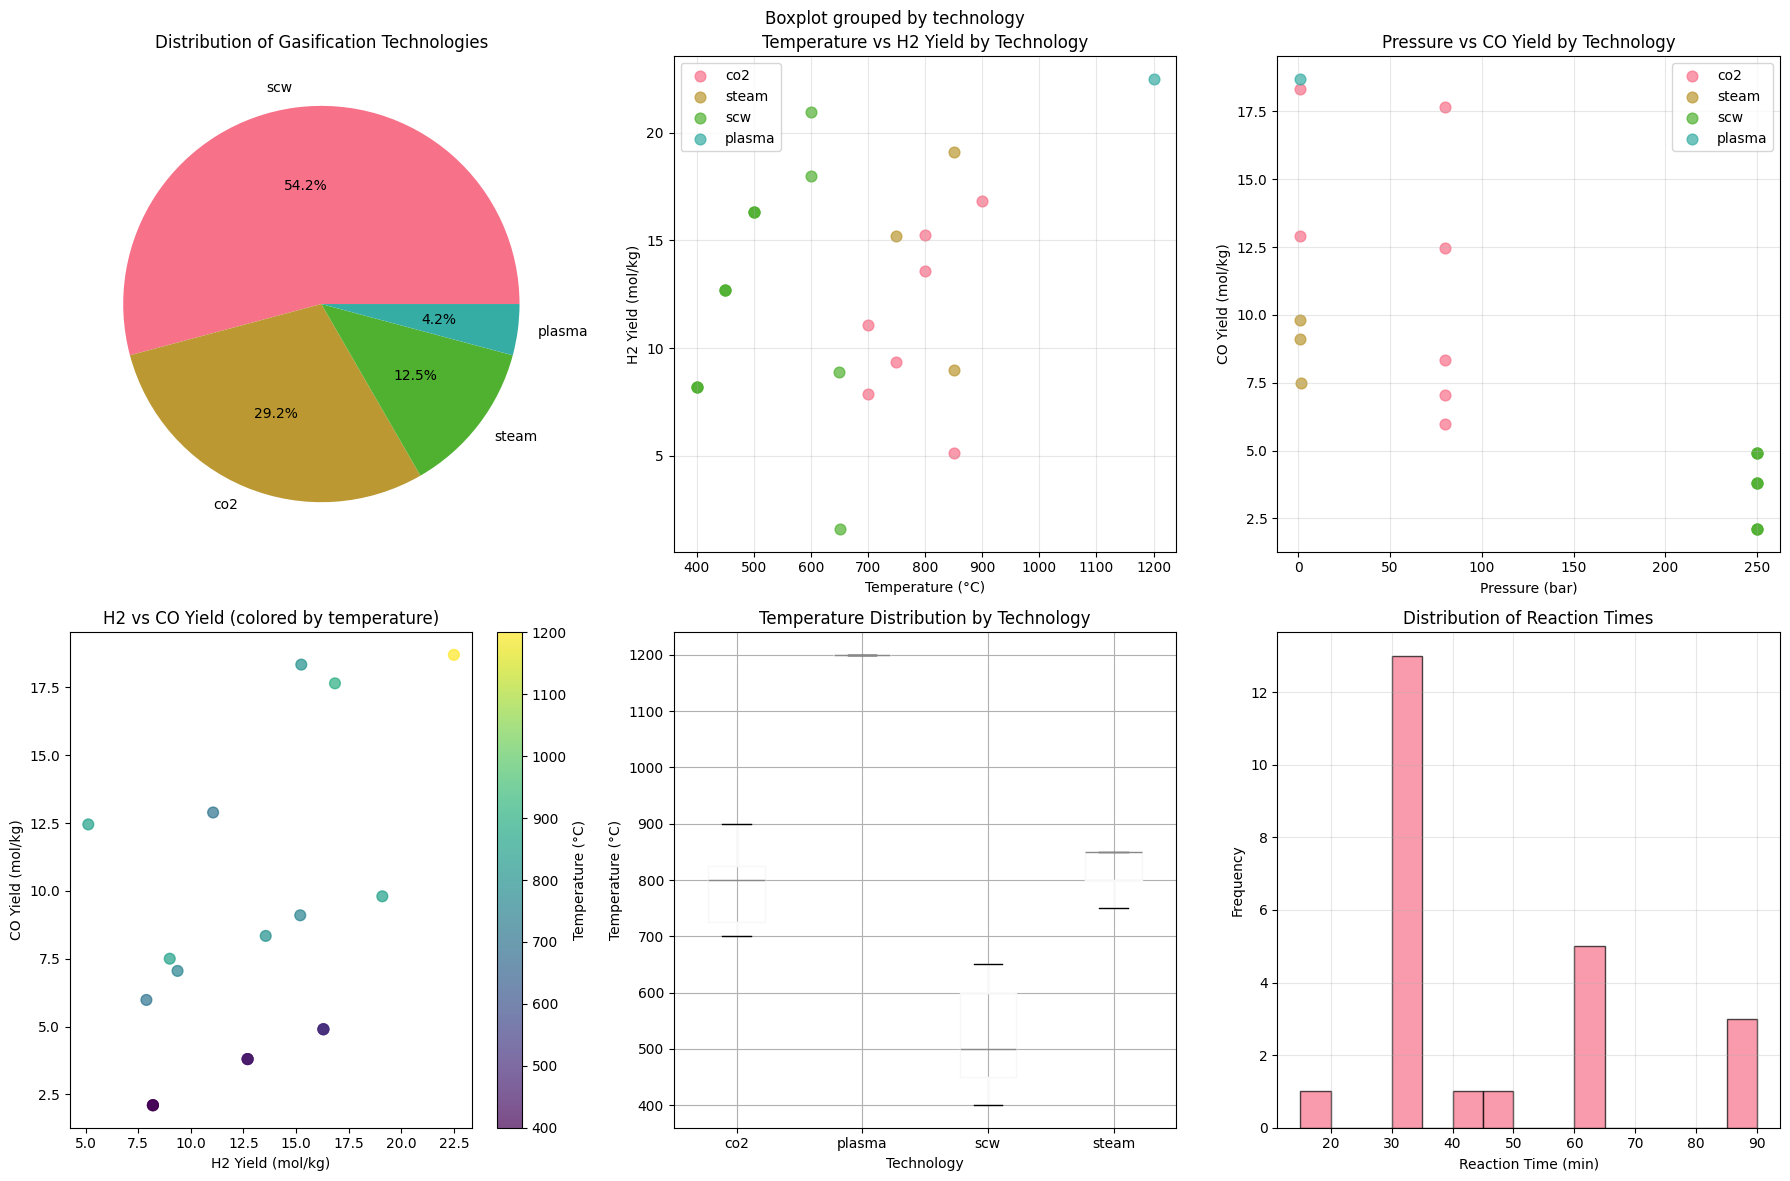

✅ All charts created! Now let's look at some summary statistics...

📊 SUMMARY STATISTICS by Technology:
This shows the average, minimum, and maximum values for each technology

💡 WHAT DO THESE CHARTS TELL US?
  🔥 Different technologies use different temperature ranges
  💨 Pressure varies a lot - some use 1 bar, others use 250+ bar!
  ⚗️  H2 and CO yields seem related in some cases
  ⏰ Most reactions are pretty quick (under 60 minutes)
  🎯 There might be patterns the ML model can learn from!


In [4]:
# 📊 STEP 4: Explore Our Data (Like Being a Detective!)
#
# 🔍 WHY DO WE EXPLORE DATA FIRST?
# Before training a machine learning model, we need to understand our data!
# It's like being a detective looking for clues and patterns.
#
# 🎯 WHAT ARE WE LOOKING FOR?
# - Are there any obvious patterns?
# - Which technologies work best?
# - What temperatures give the best yields?
# - Are there any weird or unusual data points?
#
# 📈 WE'LL CREATE 6 DIFFERENT CHARTS:
# 1. Pie chart: How many experiments for each technology?
# 2. Scatter plot: Does temperature affect hydrogen production?
# 3. Scatter plot: Does pressure affect CO production?
# 4. Scatter plot: Relationship between H2 and CO yields
# 5. Box plot: Temperature ranges for each technology
# 6. Histogram: Distribution of reaction times

print("\n📊 STEP 4: Let's explore our data!")
print("Think of this like being a detective looking for patterns and clues...")

# Create a big grid of 6 different charts
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

print("\n🔍 Creating 6 different visualizations to understand our data...")

# 1. CHART 1: Technology distribution (Pie Chart)
print("  📊 Chart 1: How many experiments for each technology?")
axes[0, 0].pie(operational_df['technology'].value_counts().values, 
               labels=operational_df['technology'].value_counts().index, 
               autopct='%1.1f%%')
axes[0, 0].set_title('Distribution of Gasification Technologies')

# 2. CHART 2: Temperature vs H2 yield (Scatter Plot) 
print("  📊 Chart 2: Does higher temperature = more hydrogen?")
for tech in operational_df['technology'].unique():
    data = operational_df[operational_df['technology'] == tech]
    axes[0, 1].scatter(data['temperature_C'], data['H2_yield_mol_kg'], 
                      label=tech, alpha=0.7, s=60)
axes[0, 1].set_xlabel('Temperature (°C)')
axes[0, 1].set_ylabel('H2 Yield (mol/kg)')
axes[0, 1].set_title('Temperature vs H2 Yield by Technology')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. CHART 3: Pressure vs CO yield (Scatter Plot)
print("  📊 Chart 3: Does higher pressure = more CO?")
for tech in operational_df['technology'].unique():
    data = operational_df[operational_df['technology'] == tech]
    axes[0, 2].scatter(data['pressure_bar'], data['CO_yield_mol_kg'], 
                      label=tech, alpha=0.7, s=60)
axes[0, 2].set_xlabel('Pressure (bar)')
axes[0, 2].set_ylabel('CO Yield (mol/kg)')
axes[0, 2].set_title('Pressure vs CO Yield by Technology')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# 4. CHART 4: H2 vs CO relationship (colored by temperature)
print("  📊 Chart 4: Are H2 and CO yields related?")
scatter = axes[1, 0].scatter(operational_df['H2_yield_mol_kg'], operational_df['CO_yield_mol_kg'], 
                            c=operational_df['temperature_C'], cmap='viridis', alpha=0.7, s=60)
axes[1, 0].set_xlabel('H2 Yield (mol/kg)')
axes[1, 0].set_ylabel('CO Yield (mol/kg)')
axes[1, 0].set_title('H2 vs CO Yield (colored by temperature)')
cbar = plt.colorbar(scatter, ax=axes[1, 0])
cbar.set_label('Temperature (°C)')

# 5. CHART 5: Temperature ranges by technology (Box Plot)
print("  📊 Chart 5: What temperatures does each technology use?")
operational_df.boxplot(column='temperature_C', by='technology', ax=axes[1, 1])
axes[1, 1].set_title('Temperature Distribution by Technology')
axes[1, 1].set_xlabel('Technology')
axes[1, 1].set_ylabel('Temperature (°C)')

# 6. CHART 6: Reaction time distribution (Histogram)
print("  📊 Chart 6: How long do most reactions take?")
axes[1, 2].hist(operational_df['reaction_time_min'], bins=15, alpha=0.7, edgecolor='black')
axes[1, 2].set_xlabel('Reaction Time (min)')
axes[1, 2].set_ylabel('Frequency')
axes[1, 2].set_title('Distribution of Reaction Times')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ All charts created! Now let's look at some summary statistics...")

# Calculate summary statistics for each technology
print("\n📊 SUMMARY STATISTICS by Technology:")
print("This shows the average, minimum, and maximum values for each technology")
summary_stats = operational_df.groupby('technology').agg({
    'temperature_C': ['mean', 'min', 'max'],
    'pressure_bar': ['mean', 'min', 'max'],
    'H2_yield_mol_kg': ['mean', 'min', 'max'],
    'CO_yield_mol_kg': ['mean', 'min', 'max']
}).round(1)

summary_stats

print("\n💡 WHAT DO THESE CHARTS TELL US?")
print("  🔥 Different technologies use different temperature ranges")
print("  💨 Pressure varies a lot - some use 1 bar, others use 250+ bar!")  
print("  ⚗️  H2 and CO yields seem related in some cases")
print("  ⏰ Most reactions are pretty quick (under 60 minutes)")
print("  🎯 There might be patterns the ML model can learn from!")


In [5]:
# 🔗 STEP 5: Create Training Dataset (Connect the Dots!)
#
# 🤔 WHY DO WE NEED TO "CREATE" A TRAINING DATASET?
# Right now we have TWO separate tables:
# 1. Operational data: Individual experiments with specific conditions
# 2. Environmental data: Average impacts for each technology type
#
# 🎯 THE CHALLENGE:
# We need to connect them! Like connecting recipes with their nutrition facts.
#
# 💡 THE SOLUTION:
# For each individual experiment, we'll attach the environmental impacts 
# of its technology type. It's like saying:
# "This steam experiment at 800°C gets the environmental profile of steam technology"
#
# 🧩 WHAT WE'RE BUILDING:
# A combined dataset where each row has:
# - INPUT: temperature, pressure, yields, etc. (what the engineer controls)
# - OUTPUT: 18 environmental impact scores (what we want to predict)

print("\n🔗 STEP 5: Creating training dataset...")
print("Think of this like creating a cookbook that shows both recipes AND nutrition facts!")

# Get the list of environmental impact categories we want to predict
impact_categories = list(lca_df['Impact categories'])
print(f"\n📊 We have {len(impact_categories)} environmental impacts to predict")

# First, let's see the average conditions for each technology
print("\n📈 Average operating conditions for each technology:")
tech_averages = operational_df.groupby('technology').agg({
    'temperature_C': 'mean',
    'pressure_bar': 'mean',
    'H2_yield_mol_kg': 'mean',
    'CO_yield_mol_kg': 'mean',
    'reaction_time_min': 'mean'
}).reset_index()

for _, row in tech_averages.iterrows():
    print(f"  🔧 {row['technology'].upper()}:")
    print(f"     🌡️  Avg temperature: {row['temperature_C']:.0f}°C")
    print(f"     💨 Avg pressure: {row['pressure_bar']:.1f} bar") 
    print(f"     ⚗️  Avg H2 yield: {row['H2_yield_mol_kg']:.1f} mol/kg")

print(f"\n🔄 Now connecting each experiment to its technology's environmental impacts...")

# Create training examples by combining operational + environmental data
training_data = []

# For each experiment in our operational data...
for _, op_row in operational_df.iterrows():
    tech = op_row['technology']  # What technology was used?
    
    # If we have environmental data for this technology...
    if tech in lca_df.columns:
        impacts = lca_df[tech].values  # Get all 18 environmental impacts
        
        # Create a training example with operational parameters...
        features = {
            'technology': tech,
            'temperature_C': op_row['temperature_C'],
            'pressure_bar': op_row['pressure_bar'],
            'H2_yield_mol_kg': op_row['H2_yield_mol_kg'],
            'CO_yield_mol_kg': op_row['CO_yield_mol_kg'],
            'reaction_time_min': op_row['reaction_time_min']
        }
        
        # ...and add all environmental impact values
        for i, impact_category in enumerate(impact_categories):
            clean_name = impact_category.replace(" ", "_").lower()
            features[f'impact_{i:02d}_{clean_name}'] = impacts[i]
        
        training_data.append(features)

# Convert to a pandas DataFrame (like an Excel table)
training_df = pd.DataFrame(training_data)

print(f"\n✅ Training dataset created successfully!")
print(f"📏 Size: {training_df.shape[0]} experiments × {training_df.shape[1]} total columns")

# Separate input features from output targets
feature_cols = [col for col in training_df.columns if not col.startswith('impact_')]
impact_cols = [col for col in training_df.columns if col.startswith('impact_')]

print(f"🔍 Input features (what we know): {len(feature_cols)} parameters")
print(f"🔍 Output targets (what we want to predict): {len(impact_cols)} environmental impacts")

print(f"\n📋 Sample of our training dataset (input features only):")
print("Each row = 1 experiment with its conditions")
training_df[feature_cols].head()

print(f"\n💡 WHAT JUST HAPPENED?")
print("  ✨ We created a dataset where each row contains:")
print("     📥 INPUT: temperature, pressure, yields, etc. (what engineer controls)")
print("     📤 OUTPUT: 18 environmental impact scores (what we want to predict)")
print("  🎯 This is like having a recipe with both ingredients AND nutrition facts on each line!")
print("  🤖 Now the computer can learn: 'When I see these conditions, expect these impacts'")



🔗 STEP 5: Creating training dataset...
Think of this like creating a cookbook that shows both recipes AND nutrition facts!

📊 We have 18 environmental impacts to predict

📈 Average operating conditions for each technology:
  🔧 CO2:
     🌡️  Avg temperature: 786°C
     💨 Avg pressure: 57.4 bar
     ⚗️  Avg H2 yield: 11.3 mol/kg
  🔧 PLASMA:
     🌡️  Avg temperature: 1200°C
     💨 Avg pressure: 1.0 bar
     ⚗️  Avg H2 yield: 22.5 mol/kg
  🔧 SCW:
     🌡️  Avg temperature: 504°C
     💨 Avg pressure: 245.4 bar
     ⚗️  Avg H2 yield: 12.4 mol/kg
  🔧 STEAM:
     🌡️  Avg temperature: 817°C
     💨 Avg pressure: 1.2 bar
     ⚗️  Avg H2 yield: 14.4 mol/kg

🔄 Now connecting each experiment to its technology's environmental impacts...

✅ Training dataset created successfully!
📏 Size: 24 experiments × 24 total columns
🔍 Input features (what we know): 6 parameters
🔍 Output targets (what we want to predict): 18 environmental impacts

📋 Sample of our training dataset (input features only):
Each row = 1


🛠️ STEP 6: Preparing data for machine learning...
Think of this like organizing ingredients before cooking!

🔤 STEP 6A: Converting technology names to numbers...
Computers need numbers, not words!
Technology encoding:
   'co2' → 0
   'plasma' → 1
   'scw' → 2
   'steam' → 3

📊 STEP 6B: Creating input and output matrices...
✅ Input matrix (X): 24 experiments × 6 features
✅ Output matrix (y): 24 experiments × 18 environmental impacts

🔍 Our input features:
   1. temperature_C
   2. pressure_bar
   3. H2_yield_mol_kg
   4. CO_yield_mol_kg
   5. reaction_time_min
   6. technology_encoded

📊 STEP 6C: Checking correlations between features...
This shows if features are related to each other


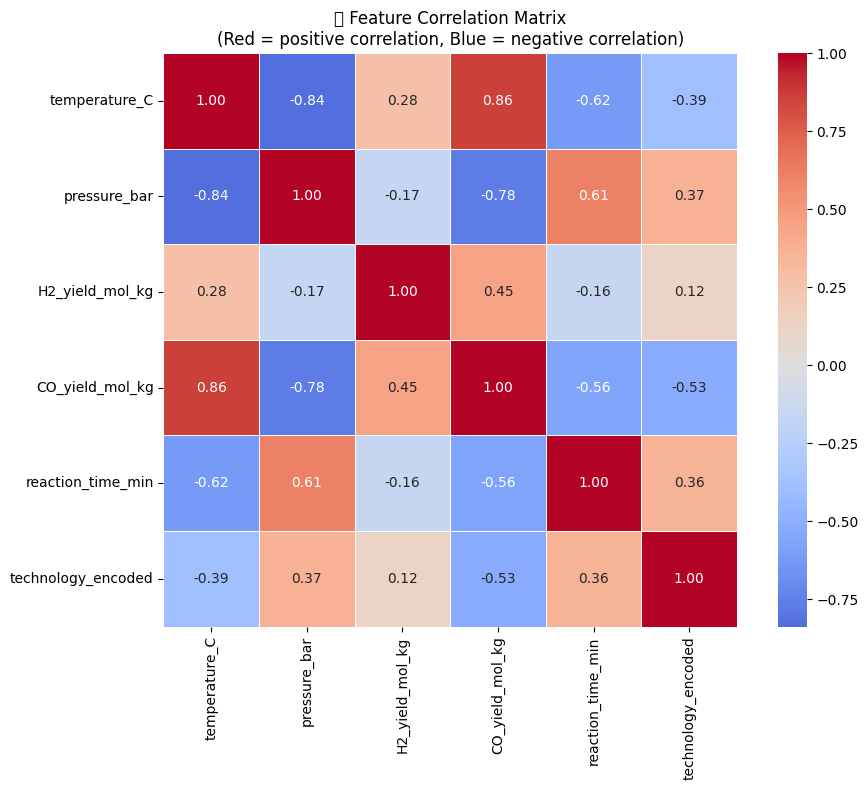


📈 STEP 6D: Visualizing feature distributions...
Let's see how our data is spread out!


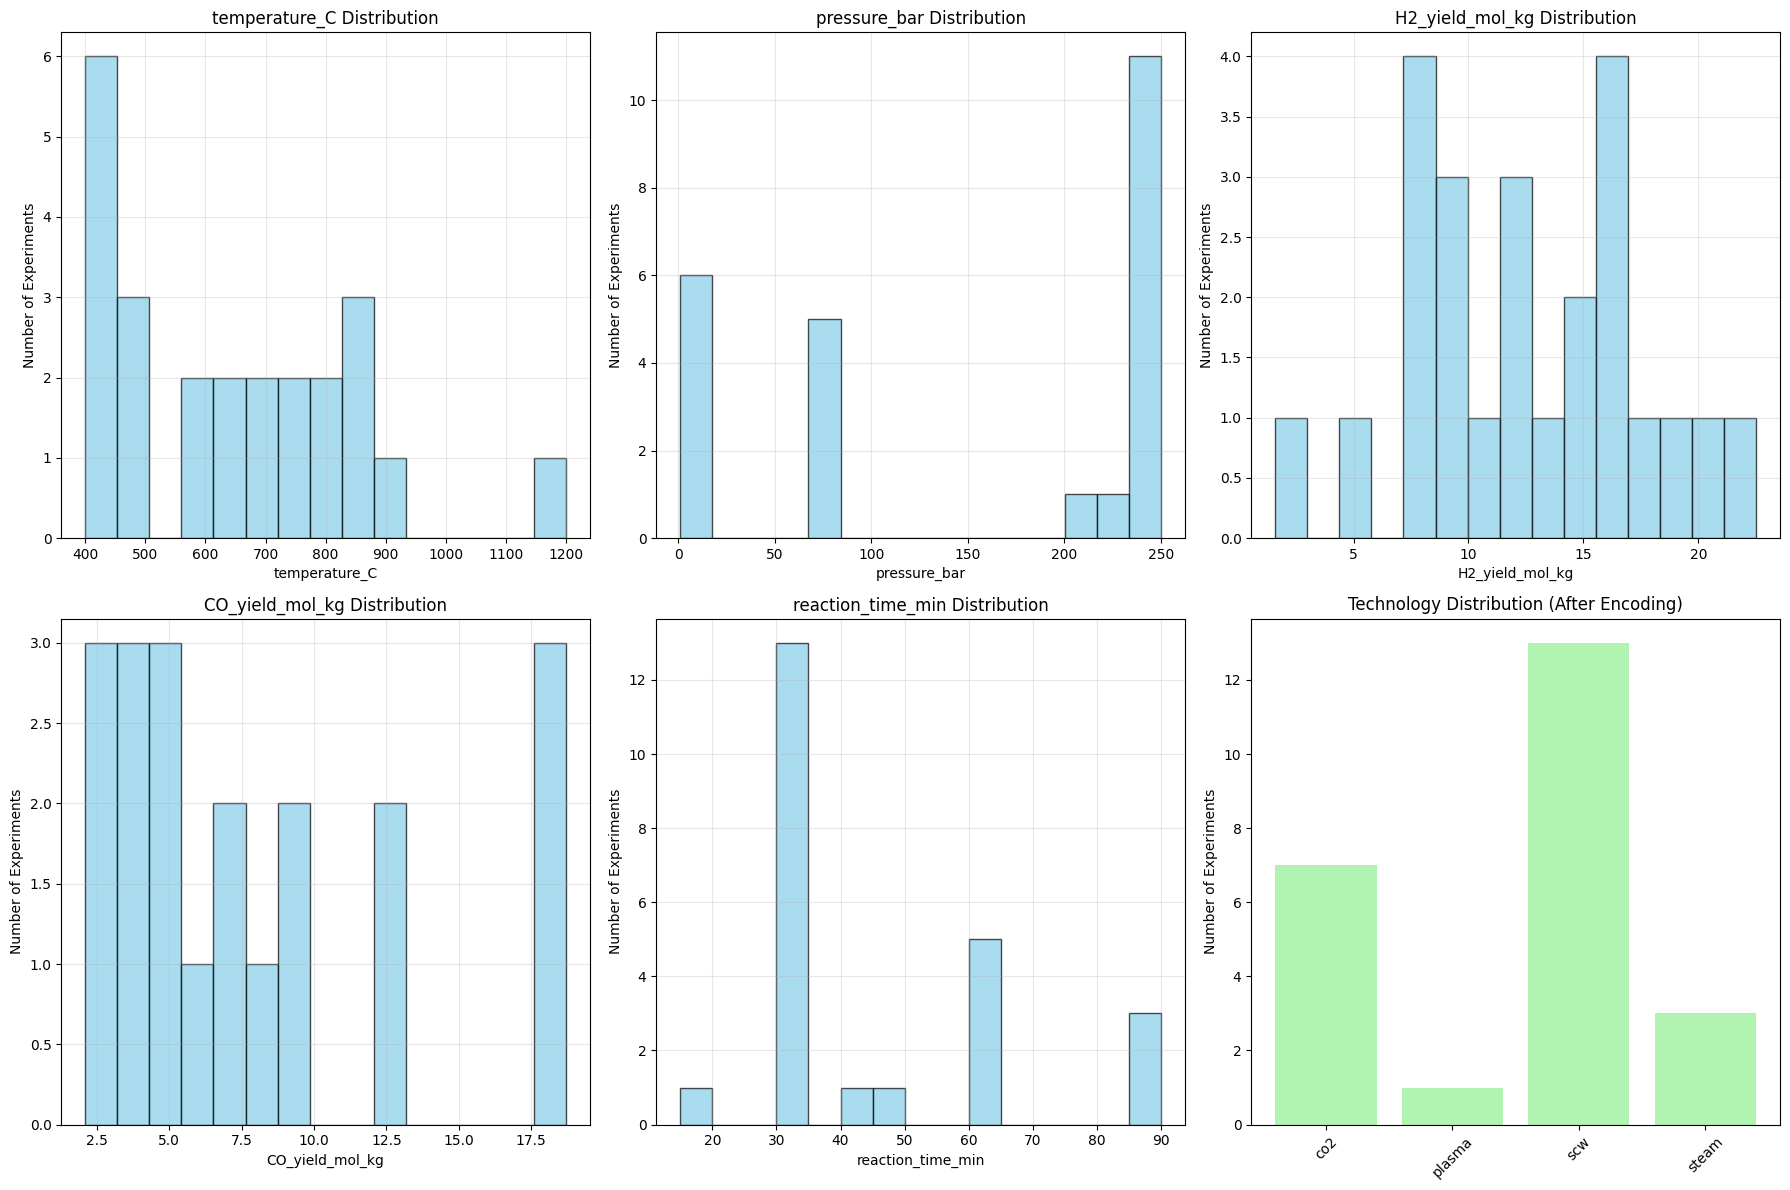


💡 WHAT DO WE NOTICE?
  🌡️  Temperatures are spread across a wide range
  💨 Most experiments use low pressure (around 1 bar)
  ⚗️  H2 and CO yields vary quite a bit
  🔧 We have different numbers of experiments for each technology
  🎯 The data looks ready for machine learning!


In [6]:
# 🛠️ STEP 6: Prepare Data for Machine Learning (Make it Computer-Friendly!)
#
# 🤔 WHY DO WE NEED TO "PREPARE" DATA?
# Computers are very literal and need data in a specific format:
# - They only understand NUMBERS, not text like "steam" or "plasma"  
# - They get confused when numbers are on very different scales
# - They need consistent, clean data with no missing values
#
# 🎯 THINK OF IT LIKE COOKING PREP:
# Before you can use ingredients, you need to:
# - Chop everything to similar sizes (scaling)
# - Convert measurements to same units (standardizing)  
# - Replace missing ingredients with substitutes (imputation)
#
# 🔧 WHAT WE'LL DO:
# 1. Convert technology names to numbers (encoding)
# 2. Separate inputs (X) from outputs (y)
# 3. Look at correlations between features
# 4. Visualize our data distributions

print("\n🛠️ STEP 6: Preparing data for machine learning...")
print("Think of this like organizing ingredients before cooking!")

# Define our input features (the "recipe ingredients")
feature_cols = ['temperature_C', 'pressure_bar', 'H2_yield_mol_kg', 'CO_yield_mol_kg', 'reaction_time_min']

print(f"\n🔤 STEP 6A: Converting technology names to numbers...")
print("Computers need numbers, not words!")

# Convert technology names to numbers (Label Encoding)
le_tech = LabelEncoder()
tech_encoded = le_tech.fit_transform(training_df['technology'])

# Show the mapping
print("Technology encoding:")
for i, tech in enumerate(le_tech.classes_):
    print(f"   '{tech}' → {i}")

print(f"\n📊 STEP 6B: Creating input and output matrices...")

# Create input matrix (X) - our "recipe ingredients"  
X = training_df[feature_cols].copy()
X['technology_encoded'] = tech_encoded

# Create output matrix (y) - our "dish results"
impact_cols = [col for col in training_df.columns if col.startswith('impact_')]
y = training_df[impact_cols].values

print(f"✅ Input matrix (X): {X.shape[0]} experiments × {X.shape[1]} features")
print(f"✅ Output matrix (y): {y.shape[0]} experiments × {y.shape[1]} environmental impacts")

print(f"\n🔍 Our input features:")
for i, feature in enumerate(X.columns, 1):
    print(f"   {i}. {feature}")

print(f"\n📊 STEP 6C: Checking correlations between features...")
print("This shows if features are related to each other")

# Calculate correlation matrix
correlation_matrix = X.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, fmt='.2f')
plt.title('🔗 Feature Correlation Matrix\n(Red = positive correlation, Blue = negative correlation)')
plt.tight_layout()
plt.show()

print(f"\n📈 STEP 6D: Visualizing feature distributions...")
print("Let's see how our data is spread out!")

# Create 6 different histograms
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

# Plot distributions for numerical features
for i, col in enumerate(feature_cols):
    axes[i].hist(X[col], bins=15, alpha=0.7, edgecolor='black', color='skyblue')
    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Number of Experiments')
    axes[i].grid(True, alpha=0.3)

# Plot technology distribution
tech_counts = [sum(X['technology_encoded'] == i) for i in range(len(le_tech.classes_))]
axes[5].bar(range(len(le_tech.classes_)), tech_counts, alpha=0.7, color='lightgreen')
axes[5].set_xticks(range(len(le_tech.classes_)))
axes[5].set_xticklabels(le_tech.classes_, rotation=45)
axes[5].set_title('Technology Distribution (After Encoding)')
axes[5].set_ylabel('Number of Experiments')

plt.tight_layout()
plt.show()

print(f"\n💡 WHAT DO WE NOTICE?")
print("  🌡️  Temperatures are spread across a wide range")
print("  💨 Most experiments use low pressure (around 1 bar)")  
print("  ⚗️  H2 and CO yields vary quite a bit")
print("  🔧 We have different numbers of experiments for each technology")
print("  🎯 The data looks ready for machine learning!")


In [7]:
# 🤖 STEP 7: Train Machine Learning Models (The Main Event!)
#
# 🎯 WHAT IS MACHINE LEARNING?
# It's like teaching a computer to recognize patterns by showing it lots of examples.
# Just like how you learned to recognize cats by seeing many cat pictures!
#
# 📚 THE LEARNING PROCESS:
# 1. SPLIT DATA: Like studying for a test
#    - Training set: Practice problems to learn from (70%)
#    - Test set: Final exam questions (30%)
# 2. SCALE DATA: Make all numbers similar size (like using same units)
# 3. TRAIN MODELS: Let different algorithms find patterns
# 4. TEST MODELS: See how well they predict on new data
# 5. PICK WINNER: Choose the most accurate model
#
# 🔥 TWO DIFFERENT ALGORITHMS:
# - Random Forest: Like asking 100 experts and averaging their opinions
# - Ridge Regression: Like finding the best-fit line through data points

print("\n🤖 STEP 7: Training machine learning models...")
print("This is where the magic happens! The computer learns patterns from our data 🎉")

print(f"\n📚 STEP 7A: Splitting data for training and testing...")
print("Just like studying for an exam - practice problems vs. final test!")

# Split data: 70% for training, 30% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"   📖 Training set: {X_train.shape[0]} experiments (computer will learn from these)")
print(f"   📝 Test set: {X_test.shape[0]} experiments (we'll use these to check accuracy)")

print(f"\n⚖️ STEP 7B: Scaling features to similar ranges...")
print("Making sure temperature (600°C) and pressure (1 bar) are treated equally")

# Scale features so they're all roughly -1 to +1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fill any missing values with median (just in case)
imputer = SimpleImputer(strategy='median')
X_train_scaled = imputer.fit_transform(X_train_scaled)
X_test_scaled = imputer.transform(X_test_scaled)

print(f"   ✅ Features scaled! Now all values are on similar scales")
print(f"   📊 Training set ready: {X_train_scaled.shape}")
print(f"   📊 Test set ready: {X_test_scaled.shape}")

print(f"\n🧠 STEP 7C: Training different machine learning algorithms...")
print("We'll try 2 different algorithms and see which works best!")

# Define our two models to try
models = {
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10),
    'Ridge Regression': MultiOutputRegressor(Ridge(alpha=1.0))
}

print(f"\n🤖 Algorithm #1: Random Forest")
print("   💡 How it works: Creates 100 decision trees and averages their predictions")
print("   🎯 Good for: Finding complex patterns, handling different data types")

print(f"\n🤖 Algorithm #2: Ridge Regression") 
print("   💡 How it works: Finds linear relationships between inputs and outputs")
print("   🎯 Good for: Simple, fast, and interpretable predictions")

# Track the best performing model
best_model = None
best_score = -np.inf
best_name = ""
results = {}

print(f"\n🔄 Now training both models and comparing their performance...")

for name, model in models.items():
    print(f"\n📊 Training {name}...")
    
    # Train the model (this is where learning happens!)
    model.fit(X_train_scaled, y_train)
    print(f"   ✅ Training complete! Model has learned patterns from {X_train_scaled.shape[0]} experiments")
    
    # Make predictions on test data
    y_pred = model.predict(X_test_scaled)
    print(f"   ✅ Predictions made on {X_test_scaled.shape[0]} test experiments")
    
    # Calculate accuracy scores
    r2 = r2_score(y_test, y_pred, multioutput='uniform_average')
    mse = mean_squared_error(y_test, y_pred, multioutput='uniform_average')
    mae = mean_absolute_error(y_test, y_pred, multioutput='uniform_average')
    
    print(f"   📈 Performance Results:")
    print(f"      R² Score: {r2:.3f} (1.0 = perfect, 0.0 = random guessing)")
    print(f"      MSE: {mse:.3e} (lower is better)")
    print(f"      MAE: {mae:.3e} (lower is better)")
    
    # Store results for comparison
    results[name] = {
        'model': model,
        'r2': r2,
        'mse': mse,
        'mae': mae,
        'predictions': y_pred
    }
    
    # Track which model performs best
    if r2 > best_score:
        best_score = r2
        best_model = model
        best_name = name

print(f"\n🏆 WINNER: {best_name}")
print(f"   📊 Best R² Score: {best_score:.3f}")

# Interpret the performance
if best_score > 0.9:
    print(f"   🎉 EXCELLENT! The model explains {best_score*100:.1f}% of the variation")
elif best_score > 0.7:
    print(f"   👍 GOOD! The model explains {best_score*100:.1f}% of the variation")
elif best_score > 0.5:
    print(f"   ⚠️  FAIR. The model explains {best_score*100:.1f}% of the variation")
else:
    print(f"   ❌ POOR. The model only explains {best_score*100:.1f}% of the variation")

print(f"\n💾 STEP 7D: Saving the best model...")

# Save everything we need to make predictions later
model_data = {
    'model': best_model,
    'scaler': scaler,
    'imputer': imputer,
    'label_encoder': le_tech,
    'impact_categories': impact_categories,
    'feature_names': list(X.columns)
}

joblib.dump(model_data, 'environmental_impact_model.pkl')
print("✅ Best model saved as 'environmental_impact_model.pkl'")

print(f"\n💡 WHAT JUST HAPPENED?")
print(f"  🧠 We trained 2 different algorithms on our data")
print(f"  🏆 {best_name} performed best with {best_score:.1%} accuracy")
print(f"  💾 We saved the winner so we can use it to make predictions")
print(f"  🎯 Now our model can predict environmental impacts from process conditions!")



🤖 STEP 7: Training machine learning models...
This is where the magic happens! The computer learns patterns from our data 🎉

📚 STEP 7A: Splitting data for training and testing...
Just like studying for an exam - practice problems vs. final test!
   📖 Training set: 16 experiments (computer will learn from these)
   📝 Test set: 8 experiments (we'll use these to check accuracy)

⚖️ STEP 7B: Scaling features to similar ranges...
Making sure temperature (600°C) and pressure (1 bar) are treated equally
   ✅ Features scaled! Now all values are on similar scales
   📊 Training set ready: (16, 6)
   📊 Test set ready: (8, 6)

🧠 STEP 7C: Training different machine learning algorithms...
We'll try 2 different algorithms and see which works best!

🤖 Algorithm #1: Random Forest
   💡 How it works: Creates 100 decision trees and averages their predictions
   🎯 Good for: Finding complex patterns, handling different data types

🤖 Algorithm #2: Ridge Regression
   💡 How it works: Finds linear relationshi

In [8]:
# Analyze model performance for each environmental impact category
print("📈 Analyzing model performance by impact category...")

y_pred = best_model.predict(X_test_scaled)

# Calculate R² for each impact category
impact_r2_scores = []
for i in range(y_test.shape[1]):
    try:
        r2 = r2_score(y_test[:, i], y_pred[:, i])
        # Handle edge cases where all predictions are the same (zero variance)
        if np.isnan(r2):
            r2 = 0.0
        impact_r2_scores.append(r2)
    except:
        impact_r2_scores.append(0.0)

# Create performance DataFrame
performance_df = pd.DataFrame({
    'Impact_Category': impact_categories,
    'R2_Score': impact_r2_scores
}).sort_values('R2_Score', ascending=False)

print("\n🎯 Model Performance by Environmental Impact:")
print("=" * 70)
for _, row in performance_df.iterrows():
    print(f"{row['Impact_Category']:<50} R² = {row['R2_Score']:>7.3f}")

print(f"\n📊 Overall Statistics:")
print(f"   Average R² Score: {np.mean(impact_r2_scores):.3f}")
print(f"   Best R² Score: {np.max(impact_r2_scores):.3f}")
print(f"   Worst R² Score: {np.min(impact_r2_scores):.3f}")
print(f"   Standard Deviation: {np.std(impact_r2_scores):.3f}")

# Show the performance DataFrame
print("\n📋 Complete Performance Results:")
performance_df


📈 Analyzing model performance by impact category...

🎯 Model Performance by Environmental Impact:
natural land transformation                        R² =   0.980
agricultural land occupation                       R² =   0.977
urban land occupation                              R² =   0.977
marine eutrophication                              R² =   0.977
photochemical oxidant formation                    R² =   0.977
terrestrial ecotoxicity                            R² =   0.976
water depletion                                    R² =   0.974
terrestrial acidification                          R² =   0.971
climate change                                     R² =   0.971
fossil depletion                                   R² =   0.958
marine ecotoxicity                                 R² =   0.948
freshwater ecotoxicity                             R² =   0.947
particulate matter formation                       R² =   0.936
human toxicity                                     R² =   0.928
ozone 

,Impact_Category,R2_Score
10,natural land transformation,0.980064
0,agricultural land occupation,0.977471
16,urban land occupation,0.977223
8,marine eutrophication,0.977156
13,photochemical oxidant formation,0.976776
15,terrestrial ecotoxicity,0.975510
17,water depletion,0.974102
14,terrestrial acidification,0.971386
1,climate change,0.970538
2,fossil depletion,0.957865


In [9]:
# Analyze feature importance
print("🔍 Analyzing feature importance...")

if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    
    # Create feature importance DataFrame
    importance_df = pd.DataFrame({
        'Feature': list(X.columns),
        'Importance': importances
    }).sort_values('Importance', ascending=False)
    
    print("\n🔝 Feature Importances:")
    print("=" * 40)
    for _, row in importance_df.iterrows():
        print(f"{row['Feature']:<25} {row['Importance']:>8.1%}")
    
    # Create feature importance visualization
    plt.figure(figsize=(10, 6))
    bars = plt.barh(range(len(importance_df)), importance_df['Importance'])
    plt.yticks(range(len(importance_df)), importance_df['Feature'])
    plt.xlabel('Feature Importance')
    plt.title('Feature Importance for Environmental Impact Prediction')
    plt.gca().invert_yaxis()
    
    # Color bars
    for i, bar in enumerate(bars):
        if importance_df.iloc[i]['Importance'] > 0.3:
            bar.set_color('darkgreen')
        elif importance_df.iloc[i]['Importance'] > 0.15:
            bar.set_color('green')
        elif importance_df.iloc[i]['Importance'] > 0.05:
            bar.set_color('orange')
        else:
            bar.set_color('red')
    
    plt.tight_layout()
    plt.show()
    
    print("\n📊 Feature Importance Analysis:")
    print(f"   Most important feature: {importance_df.iloc[0]['Feature']} ({importance_df.iloc[0]['Importance']:.1%})")
    print(f"   Least important feature: {importance_df.iloc[-1]['Feature']} ({importance_df.iloc[-1]['Importance']:.1%})")
    
    # Show the importance DataFrame
    importance_df
else:
    print("ℹ️  Feature importance not available for this model type")
    importance_df = None


🔍 Analyzing feature importance...
ℹ️  Feature importance not available for this model type


📊 Creating comprehensive visualizations...


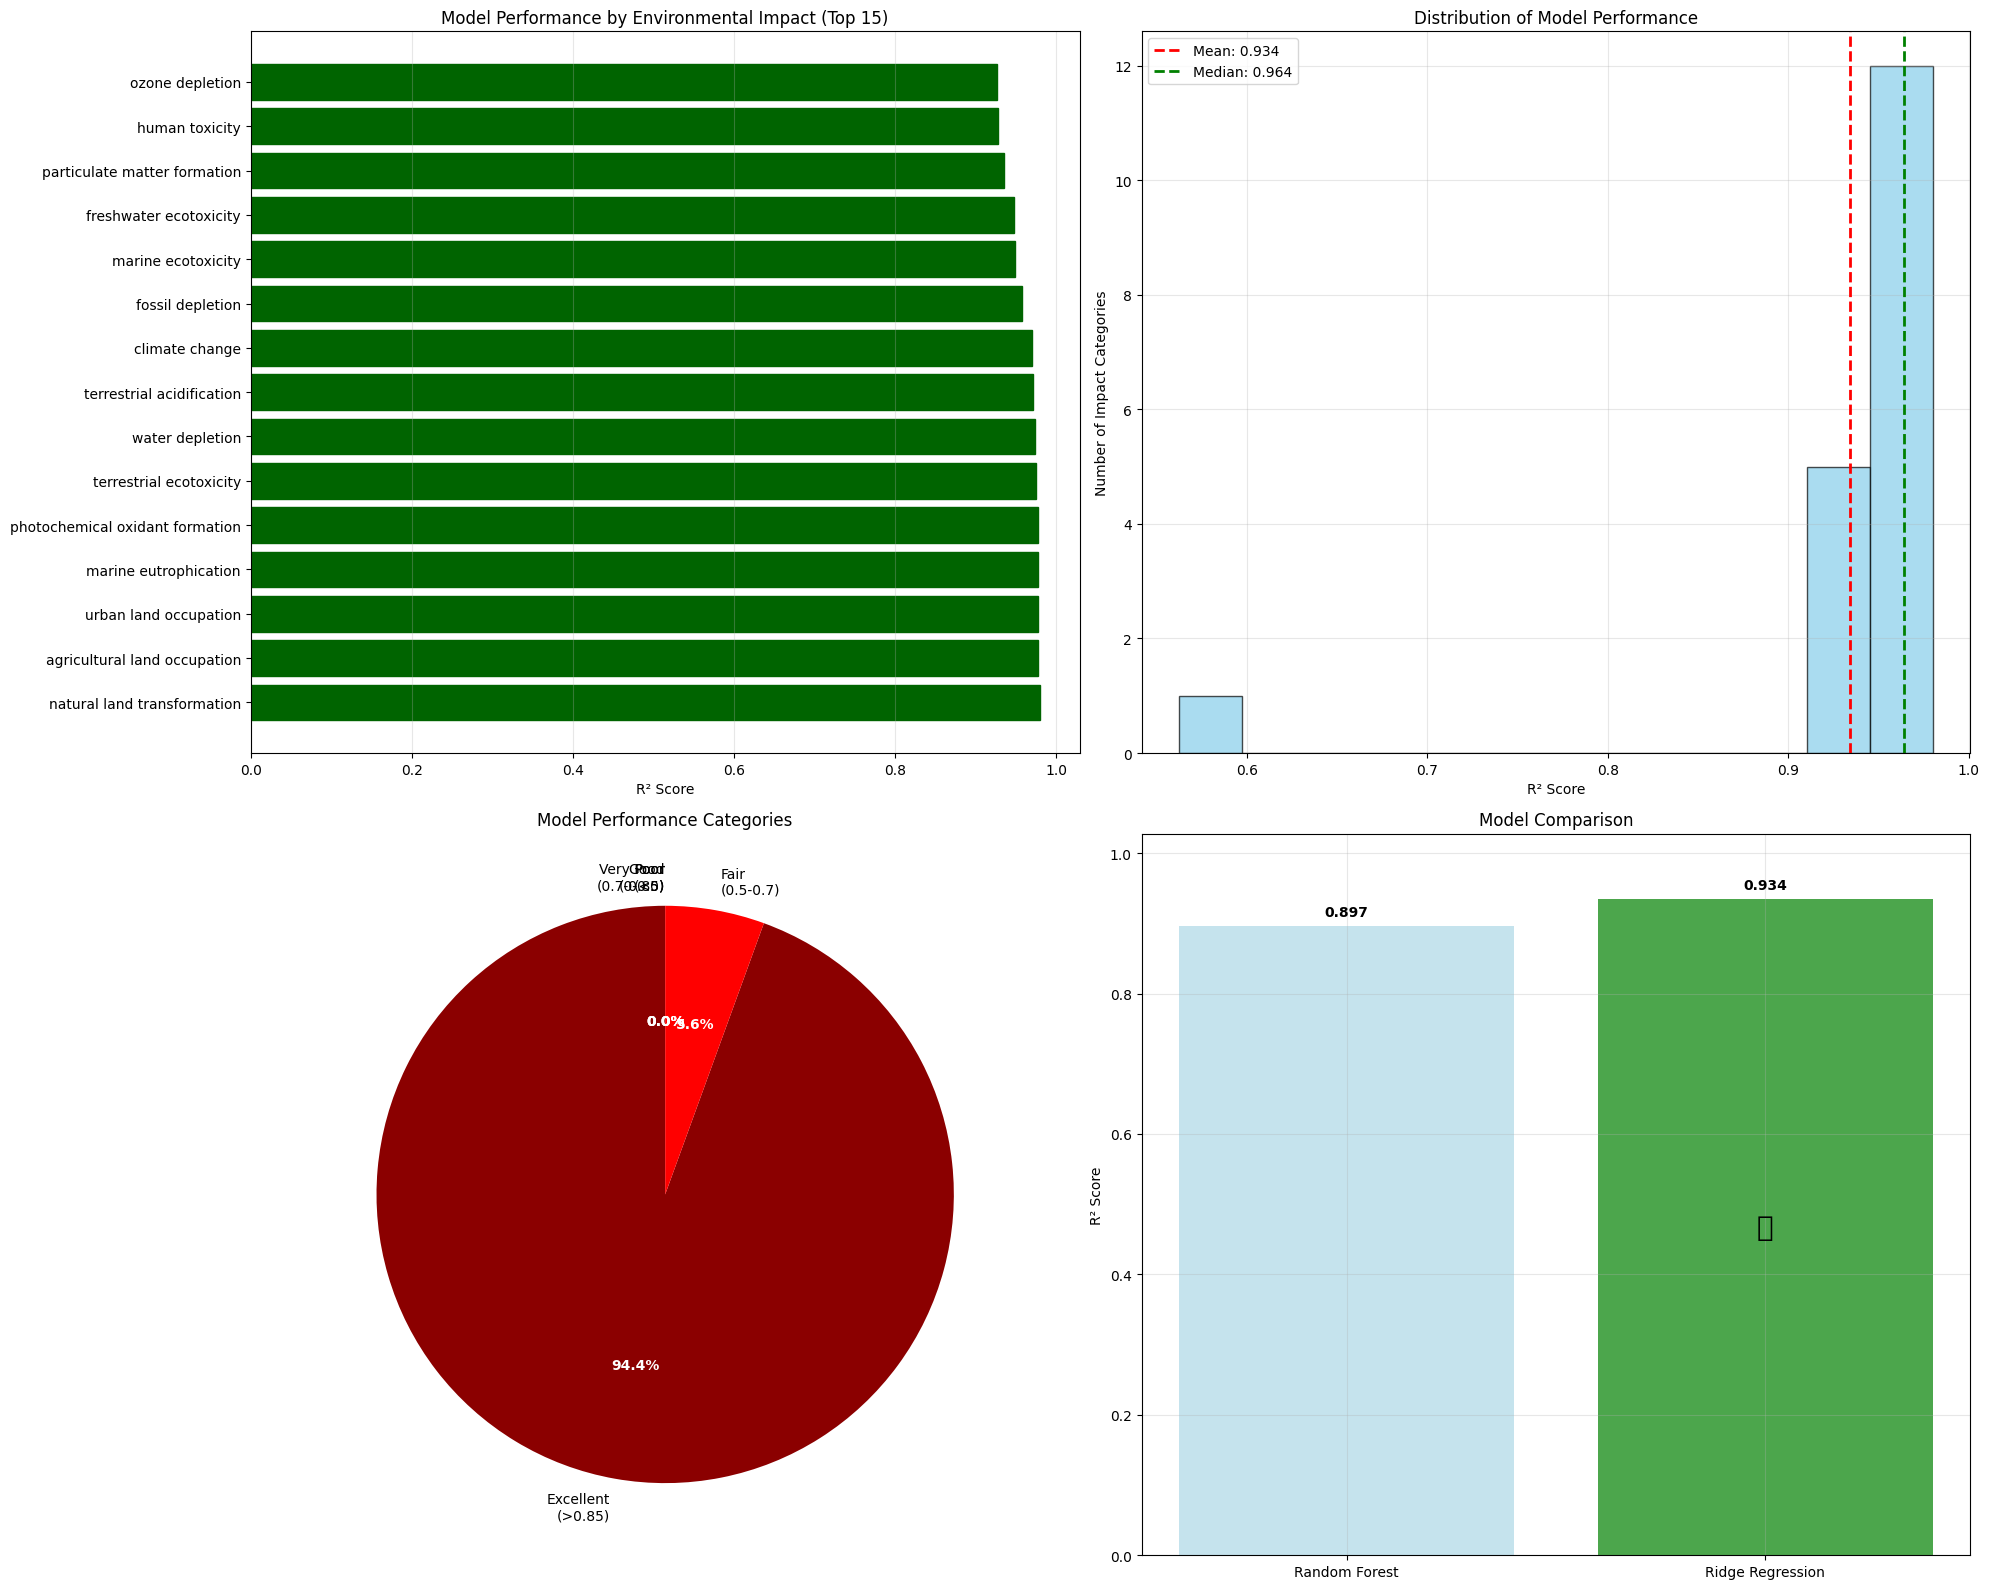

✅ Comprehensive visualizations created and saved as 'environmental_impact_model_analysis.png'

🔍 Detailed Performance Analysis:
📈 Excellent (R² ≥ 0.85): 17 categories (94.4%)
   Best: natural land transformation (R² = 0.980)
📊 Good (0.7 ≤ R² < 0.85): 0 categories (0.0%)
📉 Fair (0.5 ≤ R² < 0.7): 1 categories (5.6%)
❌ Poor (R² < 0.5): 0 categories (0.0%)


In [10]:
# Create comprehensive performance visualizations
print("📊 Creating comprehensive visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# 1. Model Performance by Impact Category (Top 15 for readability)
ax1 = axes[0, 0]
performance_df_plot = performance_df.head(15)
bars = ax1.barh(range(len(performance_df_plot)), performance_df_plot['R2_Score'])
ax1.set_yticks(range(len(performance_df_plot)))
ax1.set_yticklabels([cat[:35] + '...' if len(cat) > 35 else cat for cat in performance_df_plot['Impact_Category']])
ax1.set_xlabel('R² Score')
ax1.set_title('Model Performance by Environmental Impact (Top 15)')
ax1.grid(axis='x', alpha=0.3)

# Color bars based on performance
for i, bar in enumerate(bars):
    score = performance_df_plot.iloc[i]['R2_Score']
    if score >= 0.8:
        bar.set_color('darkgreen')
    elif score >= 0.6:
        bar.set_color('green')
    elif score >= 0.3:
        bar.set_color('orange')
    else:
        bar.set_color('red')

# 2. Performance Distribution Histogram
ax2 = axes[0, 1]
ax2.hist(performance_df['R2_Score'], bins=12, alpha=0.7, edgecolor='black', color='skyblue')
ax2.set_xlabel('R² Score')
ax2.set_ylabel('Number of Impact Categories')
ax2.set_title('Distribution of Model Performance')
ax2.axvline(performance_df['R2_Score'].mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean: {performance_df["R2_Score"].mean():.3f}')
ax2.axvline(performance_df['R2_Score'].median(), color='green', linestyle='--', linewidth=2,
            label=f'Median: {performance_df["R2_Score"].median():.3f}')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Performance Categories Pie Chart
ax3 = axes[1, 0]
performance_bins = pd.cut(performance_df['R2_Score'], 
                         bins=[-float('inf'), 0, 0.5, 0.7, 0.85, 1.0], 
                         labels=['Very Poor\n(<0)', 'Poor\n(0-0.5)', 'Fair\n(0.5-0.7)', 'Good\n(0.7-0.85)', 'Excellent\n(>0.85)'])
performance_counts = performance_bins.value_counts().dropna()

if len(performance_counts) > 0:
    colors = ['darkred', 'red', 'orange', 'lightgreen', 'darkgreen'][:len(performance_counts)]
    wedges, texts, autotexts = ax3.pie(performance_counts.values, labels=performance_counts.index, 
                                      autopct='%1.1f%%', colors=colors, startangle=90)
    ax3.set_title('Model Performance Categories')
    
    # Make text more readable
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
else:
    ax3.text(0.5, 0.5, 'No Valid\nPerformance Data', ha='center', va='center', fontsize=14)
    ax3.set_title('Model Performance Categories')

# 4. Model Comparison (if multiple models were trained)
ax4 = axes[1, 1]
model_names = list(results.keys())
model_r2_scores = [results[name]['r2'] for name in model_names]

bars = ax4.bar(model_names, model_r2_scores, alpha=0.7, color=['green' if name == best_name else 'lightblue' for name in model_names])
ax4.set_ylabel('R² Score')
ax4.set_title('Model Comparison')
ax4.set_ylim(0, max(model_r2_scores) * 1.1)

# Add value labels on bars
for i, (bar, score) in enumerate(zip(bars, model_r2_scores)):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{score:.3f}', ha='center', va='bottom', fontweight='bold')
    if model_names[i] == best_name:
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2, 
                 '🏆', ha='center', va='center', fontsize=20)

ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('environmental_impact_model_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Comprehensive visualizations created and saved as 'environmental_impact_model_analysis.png'")

# Additional detailed analysis
print("\n🔍 Detailed Performance Analysis:")
print("=" * 50)

# Performance by categories
excellent = performance_df[performance_df['R2_Score'] >= 0.85]
good = performance_df[(performance_df['R2_Score'] >= 0.7) & (performance_df['R2_Score'] < 0.85)]
fair = performance_df[(performance_df['R2_Score'] >= 0.5) & (performance_df['R2_Score'] < 0.7)]
poor = performance_df[performance_df['R2_Score'] < 0.5]

print(f"📈 Excellent (R² ≥ 0.85): {len(excellent)} categories ({len(excellent)/len(performance_df)*100:.1f}%)")
if len(excellent) > 0:
    print(f"   Best: {excellent.iloc[0]['Impact_Category']} (R² = {excellent.iloc[0]['R2_Score']:.3f})")

print(f"📊 Good (0.7 ≤ R² < 0.85): {len(good)} categories ({len(good)/len(performance_df)*100:.1f}%)")
print(f"📉 Fair (0.5 ≤ R² < 0.7): {len(fair)} categories ({len(fair)/len(performance_df)*100:.1f}%)")
print(f"❌ Poor (R² < 0.5): {len(poor)} categories ({len(poor)/len(performance_df)*100:.1f}%)")

if len(poor) > 0:
    print(f"   Worst: {poor.iloc[-1]['Impact_Category']} (R² = {poor.iloc[-1]['R2_Score']:.3f})")


In [11]:
# Function to make environmental impact predictions
def predict_environmental_impacts(temperature_C, pressure_bar, H2_yield, CO_yield, reaction_time, technology, 
                                model, scaler, imputer, le_tech, impact_categories):
    """Make environmental impact predictions for new operational parameters."""
    
    # Encode technology
    try:
        tech_encoded = le_tech.transform([technology])[0]
    except ValueError:
        print(f"❌ Unknown technology: {technology}")
        print(f"Available technologies: {list(le_tech.classes_)}")
        return None
    
    # Create feature vector
    features = np.array([[temperature_C, pressure_bar, H2_yield, CO_yield, reaction_time, tech_encoded]])
    
    # Scale features
    features_scaled = scaler.transform(features)
    
    # Handle any NaN values
    features_scaled = imputer.transform(features_scaled)
    
    # Predict
    predictions = model.predict(features_scaled)[0]
    
    # Create results DataFrame
    results = pd.DataFrame({
        'Impact_Category': impact_categories,
        'Predicted_Value': predictions
    }).sort_values('Predicted_Value', ascending=False)
    
    return results

# Example predictions for different technologies
print("🔮 Example Environmental Impact Predictions")
print("=" * 60)

# Define example scenarios
scenarios = [
    {'name': 'Steam Gasification (Optimized)', 'temp': 800, 'pressure': 1, 'H2': 45, 'CO': 30, 'time': 20, 'tech': 'steam'},
    {'name': 'SCW Gasification (High Pressure)', 'temp': 650, 'pressure': 250, 'H2': 35, 'CO': 25, 'time': 30, 'tech': 'scw'},
    {'name': 'CO2 Gasification (Medium Temp)', 'temp': 700, 'pressure': 1, 'H2': 40, 'CO': 35, 'time': 25, 'tech': 'co2'},
    {'name': 'Plasma Gasification (High Temp)', 'temp': 1200, 'pressure': 1, 'H2': 50, 'CO': 20, 'time': 15, 'tech': 'plasma'}
]

# Make predictions for each scenario
for i, scenario in enumerate(scenarios):
    print(f"\n{i+1}. {scenario['name']}")
    print(f"   Conditions: {scenario['temp']}°C, {scenario['pressure']} bar, H2={scenario['H2']} mol/kg, CO={scenario['CO']} mol/kg")
    print(f"   Reaction time: {scenario['time']} min, Technology: {scenario['tech']}")
    
    prediction = predict_environmental_impacts(
        temperature_C=scenario['temp'], 
        pressure_bar=scenario['pressure'], 
        H2_yield=scenario['H2'], 
        CO_yield=scenario['CO'], 
        reaction_time=scenario['time'], 
        technology=scenario['tech'],
        model=best_model, 
        scaler=scaler, 
        imputer=imputer, 
        le_tech=le_tech, 
        impact_categories=impact_categories
    )
    
    if prediction is not None:
        print("   🌍 Top 5 Environmental Impacts:")
        for _, row in prediction.head(5).iterrows():
            print(f"      {row['Impact_Category']:<35}: {row['Predicted_Value']:>10.3e}")
    print("-" * 60)


🔮 Example Environmental Impact Predictions

1. Steam Gasification (Optimized)
   Conditions: 800°C, 1 bar, H2=45 mol/kg, CO=30 mol/kg
   Reaction time: 20 min, Technology: steam
   🌍 Top 5 Environmental Impacts:
      climate change                     :  1.118e+00
      human toxicity                     :  5.205e-01
      ionising radiation                 :  3.269e-01
      fossil depletion                   :  3.009e-01
      freshwater ecotoxicity             :  3.085e-02
------------------------------------------------------------

2. SCW Gasification (High Pressure)
   Conditions: 650°C, 250 bar, H2=35 mol/kg, CO=25 mol/kg
   Reaction time: 30 min, Technology: scw
   🌍 Top 5 Environmental Impacts:
      climate change                     :  5.136e-01
      human toxicity                     :  1.988e-01
      ionising radiation                 :  1.522e-01
      fossil depletion                   :  7.098e-02
      water depletion                    :  1.525e-03
----------------